In [38]:
#library imports
import gcsfs
from google.cloud import storage
import pyarrow.parquet as pq
import pyarrow.fs as pafs
import pandas as pd
import tensorflow as tf
import open3d as o3d
import numpy as np


In [39]:
#get google cloud token
import os
os.environ["CLOUDSDK_CONFIG"] = "/home/jacob/.config/gcloud"

import subprocess
token = subprocess.check_output(
    ["/usr/bin/gcloud", "auth", "print-access-token"]
).decode().strip()

In [40]:
from datetime import datetime, timezone, timedelta
fs = pafs.GcsFileSystem(access_token=token, credential_token_expiration=datetime.now(timezone.utc) + timedelta(hours=1))

#list files in each folder
folders = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/"))
lidar_files = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/lidar/"))
seg_files = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/lidar_segmentation/"))
calib_files = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/lidar_calibration/"))

for f in lidar_files[:5]:
    print(f.path)

waymo_open_dataset_v_2_0_0/training/lidar/10017090168044687777_6380_000_6400_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar/10023947602400723454_1120_000_1140_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar/1005081002024129653_5313_150_5333_150.parquet
waymo_open_dataset_v_2_0_0/training/lidar/10061305430875486848_1080_000_1100_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar/10072140764565668044_4060_000_4080_000.parquet


In [41]:
#sample lidar file loading to see contents
pf_lidar = pq.ParquetFile(lidar_files[0].path, filesystem=fs)
print("Number of row groups: ", pf_lidar.metadata.num_row_groups) 
print("Array of columns: ", pf_lidar.schema) 
# cols = ["key.frame_timestamp_micros", "[LiDARComponent].range_image_return1.tensor"]
rg = pf_lidar.read_row_group(0)
df = rg.to_pandas()
df.head()

Number of row groups:  4
Array of columns:  <pyarrow._parquet.ParquetSchema object at 0x71dc8cd11b40>
required group field_id=-1 schema {
  optional binary field_id=-1 index (String);
  optional binary field_id=-1 key.segment_context_name (String);
  optional int64 field_id=-1 key.frame_timestamp_micros;
  optional int32 field_id=-1 key.laser_name (Int(bitWidth=8, isSigned=true));
  optional group field_id=-1 [LiDARComponent].range_image_return1.values (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 item;
    }
  }
  optional group field_id=-1 [LiDARComponent].range_image_return1.shape (List) {
    repeated group field_id=-1 list {
      optional int32 field_id=-1 item;
    }
  }
  optional group field_id=-1 [LiDARComponent].range_image_return2.values (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 item;
    }
  }
  optional group field_id=-1 [LiDARComponent].range_image_return2.shape (List) {
    repeated group field_id=-

,key.segment_context_name,key.frame_timestamp_micros,key.laser_name,[LiDARComponent].range_image_return1.values,[LiDARComponent].range_image_return1.shape,[LiDARComponent].range_image_return2.values,[LiDARComponent].range_image_return2.shape
index,,,,,,,
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,1,"[20.885931, 0.19042969, 1.493107, -1.0, 18.936...","[64, 2650, 4]","[-1.0, -1.0, -1.0, -1.0, 21.003038, 0.14941406...","[64, 2650, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,2,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,3,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,4,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,5,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"


In [42]:
pf_calib = pq.ParquetFile(calib_files[0].path, filesystem=fs)
rgc = pf_calib.read_row_group(0)
df_rgc = rgc.to_pandas()
df_rgc.head(5)

,key.segment_context_name,key.laser_name,[LiDARCalibrationComponent].extrinsic.transform,[LiDARCalibrationComponent].beam_inclination.min,[LiDARCalibrationComponent].beam_inclination.max,[LiDARCalibrationComponent].beam_inclination.values
0,10017090168044687777_6380_000_6400_000,2,"[0.999762602122432, 0.0036877475559088514, 0.0...",-1.570796,0.523599,None
1,10017090168044687777_6380_000_6400_000,5,"[-0.9997324974348434, -0.013945152838121559, -...",-1.570796,0.523599,None
2,10017090168044687777_6380_000_6400_000,3,"[0.013387855309090483, -0.9997985726737589, 0....",-1.570796,0.523599,None
3,10017090168044687777_6380_000_6400_000,4,"[-0.026661403897150483, 0.9996313994371858, 0....",-1.570796,0.523599,None
4,10017090168044687777_6380_000_6400_000,1,"[-0.8477724631263563, -0.5303541574199493, -0....",-0.314504,0.039886,"[-0.30925746832197243, -0.29876530723528183, -..."


### Decoding the range images (spherical coordinates) into point clouds (cartesian coordinates)


In [43]:
def sphere_to_cart(phi, rho, theta):
    horizontal_d = rho * np.cos(theta)
    X = horizontal_d * np.cos(phi)
    Y = horizontal_d * np.sin(phi)
    Z = rho * np.sin(theta)

    return X, Y, Z


laser_1_lidar = df.loc[df["key.laser_name"] == 1]
laser_1_lidar_t = laser_1_lidar.iloc[0]
#print(tuple(laser_1_lidar_t["[LiDARComponent].range_image_return1.shape"]))
#print(laser_1_lidar_t)

laser_1_lidar_t_grid = laser_1_lidar_t["[LiDARComponent].range_image_return1.values"].reshape(64, 2650, 4)
#print(laser_1_lidar_t_grid)


laser_1_calib = df_rgc.loc[df_rgc["key.laser_name"] == 1]
# extract the list of beam inclinations from the single row and convert to numpy array
theta_series = laser_1_calib["[LiDARCalibrationComponent].beam_inclination.values"].iloc[0]
theta_array = np.array(theta_series)
#print(theta_series)

phi_array = np.linspace(np.pi, np.pi * -1, num=2650)
#print(phi_array)

range_channel = laser_1_lidar_t_grid[:, :, 0]
ranges = range_channel[:, :]
range_mask = ranges > 0
print(range_mask)


[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [44]:
#apply to function

T_array, P_array = np.meshgrid(phi_array, theta_array)
# print(T_array)

X_unmasked, Y_unmasked, Z_unmasked = sphere_to_cart(P_array, range_channel, T_array)

X = X_unmasked[range_mask]
Y = Y_unmasked[range_mask]
Z = Z_unmasked[range_mask]

print("X: ", X)
print("Y: ", Y)
print("Z: ", Z)

X:  [-19.89509875 -18.03772642 -19.66062203 ...  -5.37526489  -5.63254863
  -5.77241344]
Y:  [ 6.35666265  5.76321551  6.28174523 ... -0.2069911  -0.2168986
 -0.22228453]
Z:  [ 2.55778886e-15  4.49146749e-02  9.79120532e-02 ... -2.38582871e+00
 -2.48404189e+00 -2.52937875e+00]


Using the extrensic transformation data to make the cartesian points global relative to the scene, instead of local

In [45]:
ex_transform_df= laser_1_calib["[LiDARCalibrationComponent].extrinsic.transform"].iloc[0]
ex_transform = np.array((ex_transform_df)).reshape(4, 4)
print(ex_transform)

points = np.column_stack((X, Y, Z))
homo_coords = np.column_stack((points, np.ones(len(X))))
print(points.shape)

homo_coords_T = np.transpose(homo_coords)
global_coords_T = np.dot(ex_transform, homo_coords_T)
global_coords_1 = np.transpose(global_coords_T)

#drop 4th column
global_coords = global_coords_1[:, :3]

[[-8.47772463e-01 -5.30354157e-01 -2.51365711e-03  1.43000000e+00]
 [ 5.30355440e-01 -8.47775368e-01  1.80144262e-04  0.00000000e+00]
 [-2.22655684e-03 -1.18041038e-03  9.99996825e-01  2.18400000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
(153830, 3)


Loading the labels

In [46]:
pf_seg = pq.ParquetFile(seg_files[0].path, filesystem=fs)
seg = pf_seg.read_row_group(0)
df_seg = seg.to_pandas()
df_seg.head()

,key.segment_context_name,key.frame_timestamp_micros,key.laser_name,[LiDARSegmentationLabelComponent].range_image_return1.values,[LiDARSegmentationLabelComponent].range_image_return1.shape,[LiDARSegmentationLabelComponent].range_image_return2.values,[LiDARSegmentationLabelComponent].range_image_return2.shape
index,,,,,,,
10017090168044687777_6380_000_6400_000;1550083469745187,10017090168044687777_6380_000_6400_000,1550083469745187,1,"[-1, 21, -1, 15, -1, 15, -1, 21, -1, 21, 0, 0,...","[64, 2650, 2]","[-1, 15, -1, 15, -1, 15, 0, 0, 0, 0, 0, 0, -1,...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083470245288,10017090168044687777_6380_000_6400_000,1550083470245288,1,"[-1, 17, -1, 17, -1, 17, -1, 17, -1, 21, -1, 2...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083470745363,10017090168044687777_6380_000_6400_000,1550083470745363,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083471245613,10017090168044687777_6380_000_6400_000,1550083471245613,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083471746058,10017090168044687777_6380_000_6400_000,1550083471746058,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"


In [47]:
laser_1_seg = df_seg.loc[df_seg["key.laser_name"] == 1]
laser_1_seg_t = laser_1_seg.iloc[0]
#print(laser_1_seg_t)

laser_1_seg_t_grid = laser_1_seg_t["[LiDARSegmentationLabelComponent].range_image_return1.values"].reshape(64, 2650, 2)
print(laser_1_lidar_t_grid[0])

[[ 2.0885931e+01  1.9042969e-01  1.4931070e+00 -1.0000000e+00]
 [ 1.8936110e+01  3.5888672e-02  7.6119177e-02 -1.0000000e+00]
 [ 2.0640009e+01  1.6308594e-01  9.3099612e-01 -1.0000000e+00]
 ...
 [ 1.9568483e+01  2.2363281e-01  1.1710643e-01 -1.0000000e+00]
 [ 1.5756670e+01  1.0681152e-02  8.1974499e-02 -1.0000000e+00]
 [ 2.0973761e+01  1.4062500e-01  8.9000887e-01 -1.0000000e+00]]


In [48]:
seg_grid_masked = laser_1_seg_t_grid[range_mask]
seg_grid_masked_coords = seg_grid_masked[:, 1]

print(seg_grid_masked_coords)


[21 15 15 ... 15 15 15]


Creating Functions for these methods to apply them to all LiDAR lasers

In [49]:
#processing each lidar laser for a single timeframe

def laser_process_t0(laser_num: int):

    #df == lidar folder (range image points)
    #df_rgc == calibration folder (angle of each lidar sensor)
    #df_seg == segmentation class labels

    #lidar folder processing
    laser_lidar = df.loc[df["key.laser_name"] == int(laser_num)]
    laser_lidar_t = laser_lidar.iloc[0]
    laser_shape = tuple(laser_lidar_t["[LiDARComponent].range_image_return1.shape"])
    laser_lidar_t_grid = laser_lidar_t["[LiDARComponent].range_image_return1.values"].reshape(laser_shape)

    #calibration folder processing
    laser_calib = df_rgc.loc[df_rgc["key.laser_name"] == int(laser_num)]

    if laser_calib["[LiDARCalibrationComponent].beam_inclination.values"].iloc[0] is not None:
        theta_series = laser_calib["[LiDARCalibrationComponent].beam_inclination.values"].iloc[0]

    else:
        max_inclin = laser_calib["[LiDARCalibrationComponent].beam_inclination.max"].iloc[0]
        min_inclin = laser_calib["[LiDARCalibrationComponent].beam_inclination.min"].iloc[0]
        theta_series = np.linspace(max_inclin, min_inclin, num=laser_shape[0])
    
    #converting to cartesian from spherical range image
    theta_array = np.array(theta_series)
    phi_array = np.linspace(np.pi, np.pi * -1, num=laser_shape[1])

    #range channel / masking
    range_channel = laser_lidar_t_grid[:, :, 0]
    ranges = range_channel[:, :]
    range_mask = ranges > 0

    Theta_array, Phi_array = np.meshgrid(phi_array, theta_array)

    X_unmasked, Y_unmasked, Z_unmasked = sphere_to_cart(Phi_array, range_channel, Theta_array)

    X = X_unmasked[range_mask]
    Y = Y_unmasked[range_mask]
    Z = Z_unmasked[range_mask]
    
    #extrinsic transformation (to make it global relative to the scene instead of the sensor)
    ex_transform_df= laser_calib["[LiDARCalibrationComponent].extrinsic.transform"].iloc[0]
    ex_transform = np.array((ex_transform_df)).reshape(4, 4)

    points = np.column_stack((X, Y, Z))
    homo_coords = np.column_stack((points, np.ones(len(X))))

    homo_coords_T = np.transpose(homo_coords)
    global_coords_T = np.dot(ex_transform, homo_coords_T)
    global_coords_1 = np.transpose(global_coords_T)

    #drop 4th column to get the global X, Y, Z coords
    global_coords = global_coords_1[:, :3]

    #process segmentation labels 
    laser_seg = df_seg.loc[df_seg["key.laser_name"] == int(laser_num)]
    if not laser_seg.empty:
        laser_seg_t = laser_seg.iloc[0]
    else: 
        return global_coords, np.zeros(len(global_coords), dtype=int) 
    seg_shape = tuple(laser_seg_t["[LiDARSegmentationLabelComponent].range_image_return1.shape"])
    laser_seg_t_grid = laser_seg_t["[LiDARSegmentationLabelComponent].range_image_return1.values"].reshape(seg_shape)
    
    #mask the seg grid to get the true segmentation labels of each X, Y, Z
    seg_grid_masked = laser_seg_t_grid[range_mask]
    seg_grid_masked_coords = seg_grid_masked[:, 1]

    return global_coords, seg_grid_masked_coords


In [50]:
#testing the function

g_coords, masked_labels = laser_process_t0(laser_num=4)
print("Global coords: ", global_coords)
print("Segmented labels: ", masked_labels)

Global coords:  [[ 14.92523441 -15.94049588   2.2207941 ]
 [ 13.66522954 -14.4523104    2.2622736 ]
 [ 14.76593815 -15.75260909   2.3182722 ]
 ...
 [  6.10277731  -2.67574882  -0.18960846]
 [  6.32639673  -2.803819    -0.28723679]
 [  6.44794068  -2.87343918  -0.33225573]]
Segmented labels:  [0 0 0 ... 0 0 0]


Using Open3D to visualize these points and their classes

In [51]:
#fusing the lasers, even though 2-5 aren't capturing any semantic classes, for this timestep at least

g_coords_1, masked_labels_1 = laser_process_t0(laser_num=1)
g_coords_2, masked_labels_2 = laser_process_t0(laser_num=2)
g_coords_3, masked_labels_3 = laser_process_t0(laser_num=3)
g_coords_4, masked_labels_4 = laser_process_t0(laser_num=4)
g_coords_5, masked_labels_5 = laser_process_t0(laser_num=5)

g_coords_concat = np.concatenate((g_coords_1, g_coords_2, g_coords_3, g_coords_4, g_coords_5))
masked_labels_concat = np.concatenate((masked_labels_1, masked_labels_2, masked_labels_3, masked_labels_4, masked_labels_5))

#mapping classes to labels
labels = np.unique(masked_labels_1)

kelly_colors = [
    "#444444", "#F2F3F4", "#222222", "#F3C300", "#875692", "#F38400", "#A1CAF1", "#BE0032", 
    "#C2B280", "#848482", "#008856", "#E68FAC", "#0067A5", "#F99379", "#604E97", 
    "#F6A600", "#B3446C", "#DCD300", "#882D17", "#8DB600", "#654522", "#E25822", "#2B3D26"
]

label_indexes = [i for i in range(23)]
mapping = dict(zip(label_indexes, kelly_colors))

#convert to hex for open3d viewing
def hex_to_rgb01(hex_str):                      
    h = hex_str.lstrip('#')                            
    return [int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4)]

rgb_colors = np.array([hex_to_rgb01(mapping.get(int(lbl), '#444444')) for lbl in masked_labels_concat])

#open3d visualizing - will do later, WSL issues
# pcd = o3d.geometry.PointCloud()
# pcd.points = o3d.utility.Vector3dVector(g_coords_concat.astype(np.float64))
# pcd.colors = o3d.utility.Vector3dVector(rgb_colors)

# o3d.visualization.draw([pcd])



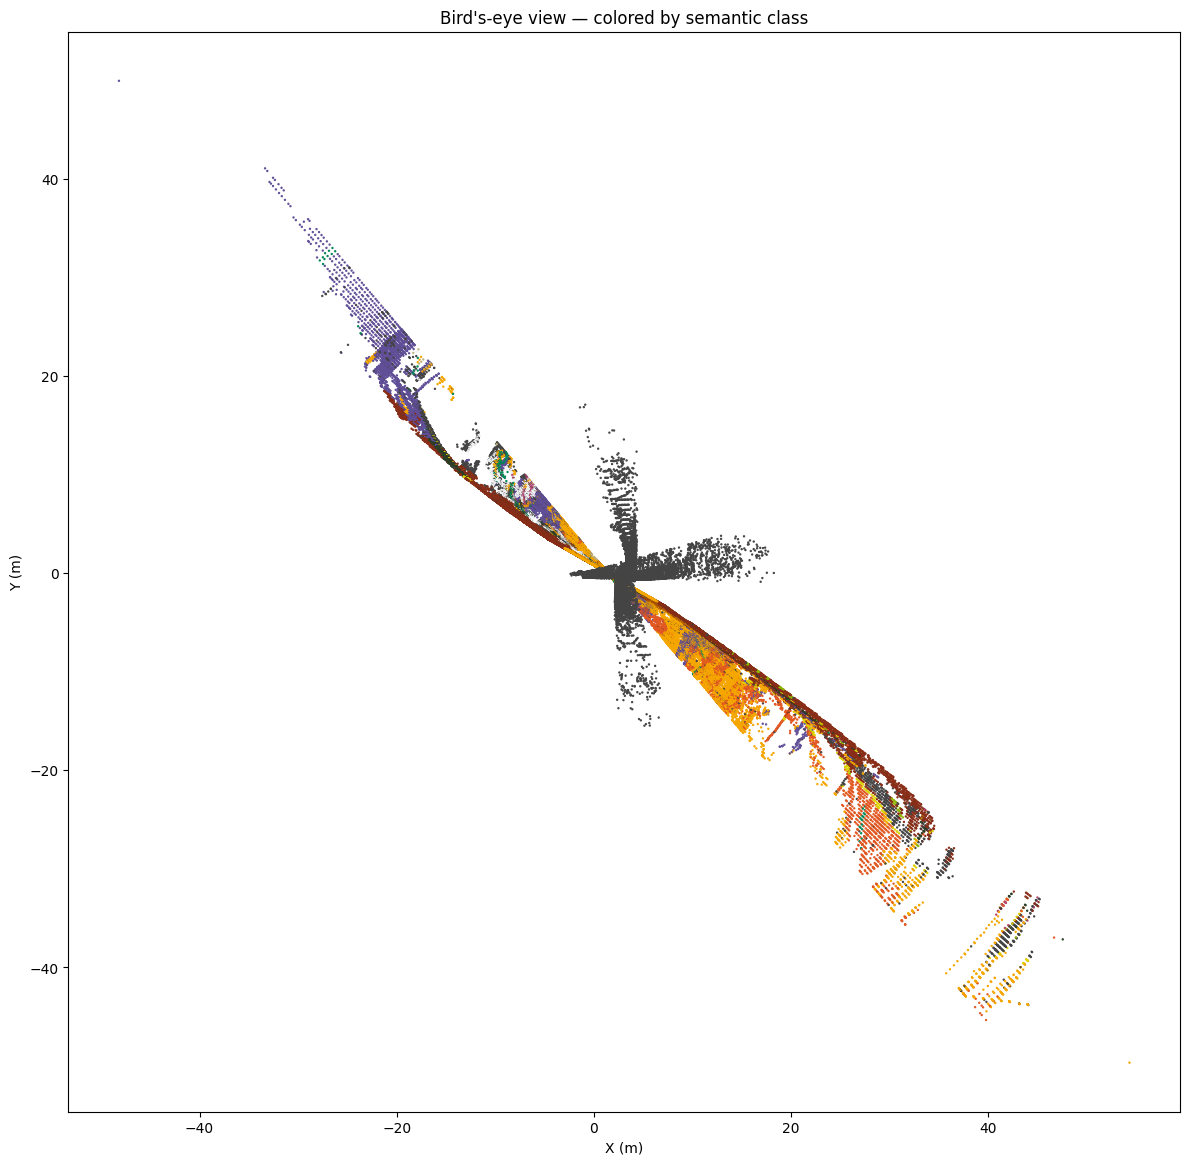

In [52]:
import matplotlib.pyplot as plt

point_colors = [mapping.get(int(lbl), '#444444') for lbl in masked_labels_concat]

fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(g_coords_concat[:, 0], g_coords_concat[:, 1], c=point_colors, s=0.5)
ax.set_aspect('equal')
ax.set_title("Bird's-eye view — colored by semantic class")
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.tight_layout()
plt.show()


This image looks strange because of it being only 200ms of LiDAR, so it is sparse.

Building the DataLoader to visualize more scenes

In [ ]:
#creating index mapping of lidar files and timestamps
file_timestamp_index = []

lidar_files = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/lidar/"))
for i in range(len(lidar_files)):
    pf_lidar = pq.ParquetFile(lidar_files[i].path, filesystem=fs)
    for j in range(pf_lidar.num_row_groups):

        rg = pf_lidar.read_row_group(j, columns=["key.frame_timestamp_micros"])
        df = rg.to_pandas()

        for stamp in df["key.frame_timestamp_micros"].unique():
            index_file_pair = tuple((lidar_files[i].path, stamp))
            file_timestamp_index.append(index_file_pair)

print(file_timestamp_index)

TypeError: ParquetFile.__init__() got an unexpected keyword argument 'columns'